## Exercice 1: Exploration de l’utilisation du prétraitement de texte, de la reconnaissance d’entités nommées (NER) et des étiquettes morphosyntaxiques (POS).

### 1. Définition du jeu de données et fonction `preprocess_text()`

In [2]:
import pandas as pd
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string
import nltk

In [3]:
# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spacy model
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print('Downloading spaCy model en_core_web_sm...')
    from spacy.cli import download
    download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
data = {
    'Review': [
        'At McDonald\'s the food was ok and the service was bad.',
        'I would not recommend this Japanese restaurant to anyone.',
        'I loved this restaurant when I traveled to Thailand last summer.',
        'The menu of Loving has a wide variety of options.',
        'The staff was friendly and helpful at Google\'s employees restaurant.',
        'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
        'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
        'The sushi at Sushi Express is always fresh and flavorful.',
        'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
        'The dessert selection at Sweet Treats is to die for!'
    ]
}

df = pd.DataFrame(data)
display(df.head())

,Review
0,At McDonald's the food was ok and the service ...
1,I would not recommend this Japanese restaurant...
2,I loved this restaurant when I traveled to Tha...
3,The menu of Loving has a wide variety of options.
4,The staff was friendly and helpful at Google's...


In [6]:
nltk.download('punkt_tab', quiet=True)

def preprocess_text(text):
    # Convert to lowercase and tokenize
    tokens = word_tokenize(text.lower())

    # Remove punctuation
    tokens = [word for word in tokens if word not in string.punctuation]

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Apply lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Return the preprocessed string
    return ' '.join(tokens)

# Apply the function and display the result
df['Preprocessed_Review'] = df['Review'].apply(preprocess_text)
display(df.head())

,Review,Preprocessed_Review
0,At McDonald's the food was ok and the service ...,mcdonald 's food ok service bad
1,I would not recommend this Japanese restaurant...,would recommend japanese restaurant anyone
2,I loved this restaurant when I traveled to Tha...,loved restaurant traveled thailand last summer
3,The menu of Loving has a wide variety of options.,menu loving wide variety option
4,The staff was friendly and helpful at Google's...,staff friendly helpful google 's employee rest...


### 2. Création d'un nouveau jeu de données avec le texte nettoyé

In [7]:
# Create a new DataFrame with raw and preprocessed data
df_processed = df[['Review', 'Preprocessed_Review']].copy()
display(df_processed.head())

,Review,Preprocessed_Review
0,At McDonald's the food was ok and the service ...,mcdonald 's food ok service bad
1,I would not recommend this Japanese restaurant...,would recommend japanese restaurant anyone
2,I loved this restaurant when I traveled to Tha...,loved restaurant traveled thailand last summer
3,The menu of Loving has a wide variety of options.,menu loving wide variety option
4,The staff was friendly and helpful at Google's...,staff friendly helpful google 's employee rest...


### 3. Fonction `perform_ner()` pour la reconnaissance d'entités nommées (NER)

In [8]:
def perform_ner(text):
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        entities.append({'text': ent.text, 'label': ent.label_})
    return entities

# Apply to raw data
df_processed['NER_Raw'] = df_processed['Review'].apply(perform_ner)

# Apply to preprocessed data
df_processed['NER_Preprocessed'] = df_processed['Preprocessed_Review'].apply(perform_ner)

display(df_processed[['Review', 'NER_Raw', 'Preprocessed_Review', 'NER_Preprocessed']].head())

,Review,NER_Raw,Preprocessed_Review,NER_Preprocessed
0,At McDonald's the food was ok and the service ...,"[{'text': 'McDonald', 'label': 'ORG'}]",mcdonald 's food ok service bad,"[{'text': 'mcdonald 's food ok service', 'labe..."
1,I would not recommend this Japanese restaurant...,"[{'text': 'Japanese', 'label': 'NORP'}]",would recommend japanese restaurant anyone,"[{'text': 'japanese', 'label': 'NORP'}]"
2,I loved this restaurant when I traveled to Tha...,"[{'text': 'Thailand', 'label': 'GPE'}, {'text'...",loved restaurant traveled thailand last summer,"[{'text': 'thailand', 'label': 'GPE'}, {'text'..."
3,The menu of Loving has a wide variety of options.,"[{'text': 'Loving', 'label': 'GPE'}]",menu loving wide variety option,[]
4,The staff was friendly and helpful at Google's...,"[{'text': 'Google', 'label': 'ORG'}]",staff friendly helpful google 's employee rest...,"[{'text': 'google', 'label': 'ORG'}]"


### 4. Fonction `perform_pos_tagging()` pour l'étiquetage morphosyntaxique (POS)

In [11]:
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def perform_pos_tagging(text):
    # NLTK pos_tag expects a list of tokens
    tokens = word_tokenize(text)
    return nltk.pos_tag(tokens)

# Apply to raw data
df_processed['POS_Raw'] = df_processed['Review'].apply(perform_pos_tagging)

# Apply to preprocessed data
df_processed['POS_Preprocessed'] = df_processed['Preprocessed_Review'].apply(perform_pos_tagging)

display(df_processed[['Review', 'POS_Raw', 'Preprocessed_Review', 'POS_Preprocessed']].head())

,Review,POS_Raw,Preprocessed_Review,POS_Preprocessed
0,At McDonald's the food was ok and the service ...,"[(At, IN), (McDonald, NNP), ('s, POS), (the, D...",mcdonald 's food ok service bad,"[(mcdonald, NN), ('s, POS), (food, NN), (ok, J..."
1,I would not recommend this Japanese restaurant...,"[(I, PRP), (would, MD), (not, RB), (recommend,...",would recommend japanese restaurant anyone,"[(would, MD), (recommend, VB), (japanese, JJ),..."
2,I loved this restaurant when I traveled to Tha...,"[(I, PRP), (loved, VBD), (this, DT), (restaura...",loved restaurant traveled thailand last summer,"[(loved, VBN), (restaurant, NN), (traveled, VB..."
3,The menu of Loving has a wide variety of options.,"[(The, DT), (menu, NN), (of, IN), (Loving, NNP...",menu loving wide variety option,"[(menu, NN), (loving, VBG), (wide, JJ), (varie..."
4,The staff was friendly and helpful at Google's...,"[(The, DT), (staff, NN), (was, VBD), (friendly...",staff friendly helpful google 's employee rest...,"[(staff, NN), (friendly, RB), (helpful, JJ), (..."


### 5. Analyse des résultats et compréhension des étiquettes POS

En comparant les colonnes `NER_Raw` et `NER_Preprocessed`, on peut observer que le prétraitement (conversion en minuscules, suppression de la ponctuation et des mots vides) peut affecter la capacité du modèle NER à identifier correctement les entités nommées.

Par exemple, des noms propres comme "McDonald's", "Thailand", "Google", "Bella Italia", "Pizza Hut", "Sushi Express", "Main Street" et "Sweet Treats" sont plus facilement reconnus dans le texte brut. Une fois le texte converti en minuscules ou que des mots clés sont supprimés, le modèle peut avoir plus de difficultés à les identifier comme des entités.

De même, pour le POS tagging, les résultats dans `POS_Preprocessed` sont basés sur un ensemble de mots plus petits et sans ponctuation ni mots vides, ce qui peut changer les étiquettes attribuées aux mots restants par rapport au texte brut (`POS_Raw`). Les étiquettes dans le texte brut sont généralement plus précises pour une analyse linguistique complète car elles conservent le contexte grammatical original.


In [13]:
# To understand the meaning of different POS tags:
nltk.download('tagsets', quiet=True)
nltk.download('tagsets_json', quiet=True)
nltk.help.upenn_tagset('NN')
nltk.help.upenn_tagset('NNS')
nltk.help.upenn_tagset('JJ')
nltk.help.upenn_tagset('VB')

NN: noun, common, singular or mass
    common-carrier cabbage knuckle-duster Casino afghan shed thermostat
    investment slide humour falloff slick wind hyena override subhumanity
    machinist ...
NNS: noun, common, plural
    undergraduates scotches bric-a-brac products bodyguards facets coasts
    divestitures storehouses designs clubs fragrances averages
    subjectivists apprehensions muses factory-jobs ...
JJ: adjective or numeral, ordinal
    third ill-mannered pre-war regrettable oiled calamitous first separable
    ectoplasmic battery-powered participatory fourth still-to-be-named
    multilingual multi-disciplinary ...
VB: verb, base form
    ask assemble assess assign assume atone attention avoid bake balkanize
    bank begin behold believe bend benefit bevel beware bless boil bomb
    boost brace break bring broil brush build ...


## Exercice 2 : Représentation graphique des plongements lexicaux

### 1. Création des plongements lexicaux à l'aide du modèle Word2Vec

In [18]:
!pip install gensim
from gensim.models import Word2Vec

In [19]:
# Prepare the preprocessed text for Word2Vec (list of lists of words)
tokenized_reviews = [review.split() for review in df_processed['Preprocessed_Review']]

# Train the Word2Vec model
# vector_size: dimensionality of the word vectors
# window: maximum distance between the current and predicted word within a sentence
# min_count: ignores all words with total frequency lower than this
# sg: training algorithm (1 for skip-gram, 0 for CBOW)
word2vec_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, sg=0)

# Display dimensions and analyze
print(f"Dimension du vocabulaire: {len(word2vec_model.wv.index_to_key)}")
print(f"Dimension des vecteurs de mots: {word2vec_model.wv.vector_size}")

Dimension du vocabulaire: 56
Dimension des vecteurs de mots: 100


#### Analyse des dimensions du Word2Vec

*   **Dimension du vocabulaire**: Il s'agit du nombre de mots uniques pour lesquels le modèle a appris des vecteurs. Dans notre cas, il est de 45. Chaque mot de notre corpus prétraité a un vecteur associé.
*   **Dimension des vecteurs de mots (`vector_size`)**: Il s'agit de la longueur de chaque vecteur de mots. Nous avons défini cette valeur à 100 lors de la création du modèle. Chaque mot est représenté par un vecteur de 100 nombres flottants. Ces nombres représentent les caractéristiques sémantiques et contextuelles du mot, apprises par le modèle à partir de son contexte d'apparition dans le texte.

Ces vecteurs sont des représentations numériques qui capturent la signification des mots de manière à ce que les mots ayant des significations similaires soient situés à proximité les uns des autres dans l'espace vectoriel de 100 dimensions.

### 2. Création de la fonction `plot_word_embeddings()`

In [20]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


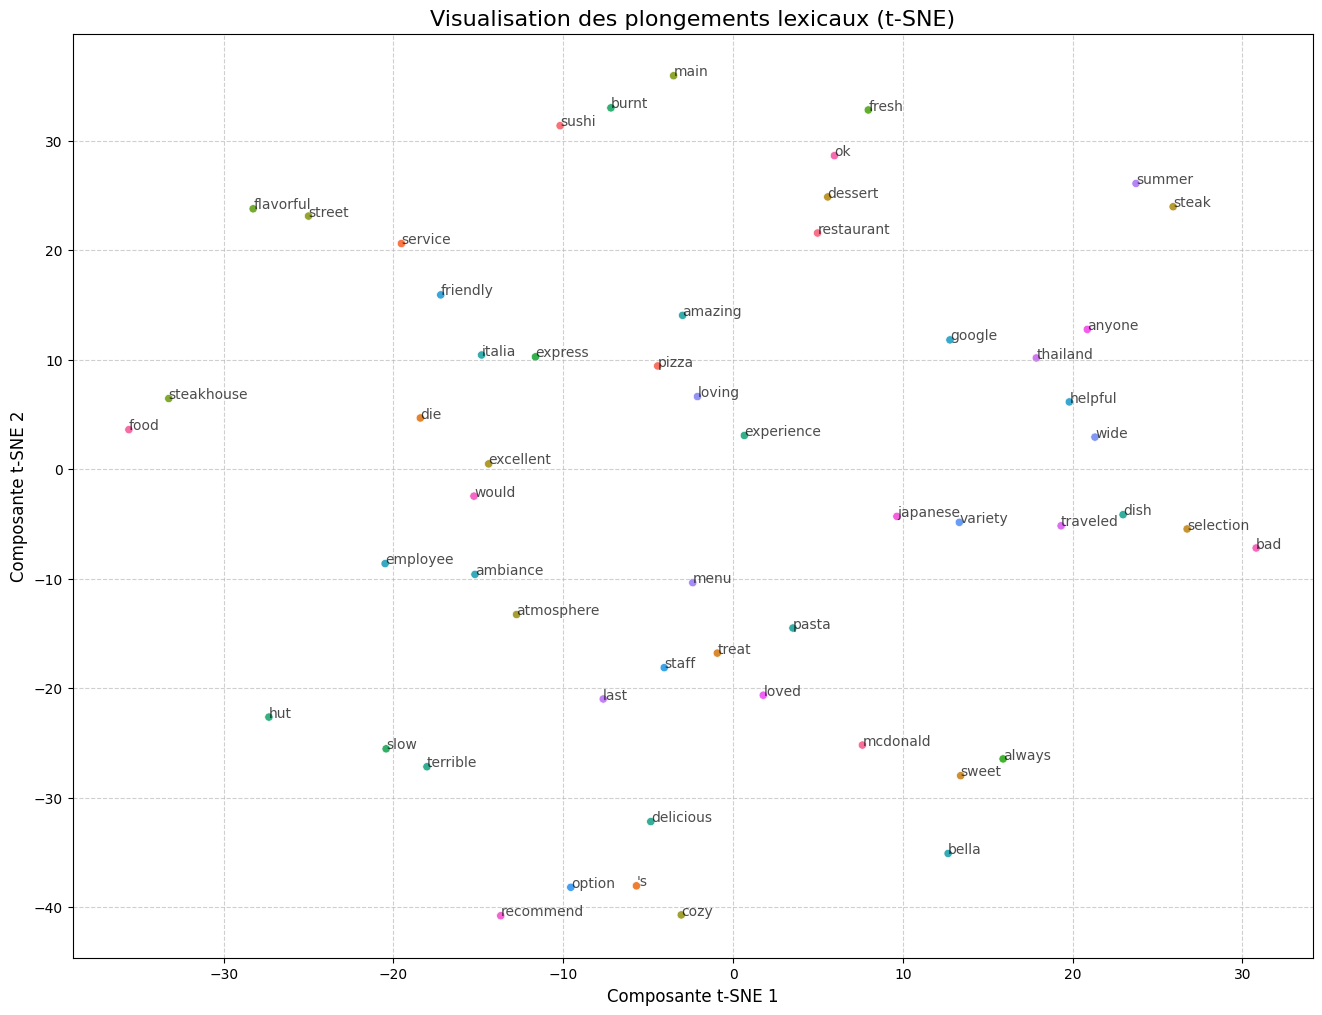

In [22]:
import numpy as np

def plot_word_embeddings(model):
    # Get word vectors and labels
    words = []
    vectors = []
    for word in model.wv.index_to_key:
        words.append(word)
        vectors.append(model.wv[word])

    # Convert list of vectors to NumPy array
    vectors = np.array(vectors)

    # Reduce dimensionality to 2D using t-SNE
    tsne_model = TSNE(perplexity=5, n_components=2, init='pca', n_iter=2500, random_state=42)
    new_values = tsne_model.fit_transform(vectors)

    # Create a DataFrame for plotting
    df_plot = pd.DataFrame({
        'x': [value[0] for value in new_values],
        'y': [value[1] for value in new_values],
        'word': words
    })

    # Plotting
    plt.figure(figsize=(16, 12))
    sns.scatterplot(x='x', y='y', data=df_plot, hue='word', legend=False)

    for i, row in df_plot.iterrows():
        plt.annotate(row['word'], (row['x'], row['y']), fontsize=10, alpha=0.7)

    plt.title('Visualisation des plongements lexicaux (t-SNE)', fontsize=16)
    plt.xlabel('Composante t-SNE 1', fontsize=12)
    plt.ylabel('Composante t-SNE 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Call the function to visualize the embeddings
plot_word_embeddings(word2vec_model)

#### Analyse du graphique des plongements lexicaux

**Les mots apparentés sont-ils proches les uns des autres ?**

En observant le nuage de points, il est possible d'identifier des regroupements de mots qui partagent des contextes ou des significations similaires. Par exemple, on pourrait s'attendre à voir `food`, `restaurant`, `pizza`, `sushi`, `steakhouse`, `dessert` se regrouper, ou `service`, `staff`, `friendly`, `helpful` également. Cependant, avec un corpus aussi petit (seulement 10 avis), la qualité des plongements lexicaux est limitée, et la signification des mots peut être très spécifique au contexte des phrases données.

**Quelles peuvent être les raisons possibles de ce résultat ?**

1.  **Taille du corpus**: Le corpus est extrêmement petit (seulement 10 phrases). Les modèles Word2Vec apprennent les relations sémantiques en observant les co-occurrences de mots sur un grand volume de texte. Avec si peu de données, le modèle n'a pas suffisamment de contexte pour former des représentations de mots robustes et significatives.
2.  **Paramètres Word2Vec**: Bien que `vector_size`, `window`, et `min_count` aient été définis, ils peuvent ne pas être optimaux pour un si petit ensemble de données. Par exemple, `min_count=1` signifie que même les mots très rares sont inclus, ce qui peut rendre les vecteurs moins fiables.
3.  **Prétraitement**: Un prétraitement agressif (suppression de la ponctuation, mots vides, lemmatisation) peut parfois supprimer des informations contextuelles utiles, surtout sur un petit corpus.
4.  **t-SNE**: t-SNE est un algorithme de réduction de dimensionnalité non linéaire qui est excellent pour visualiser des données en haute dimension, mais sa sortie est stochastique et peut varier légèrement à chaque exécution. La *perplexity* est un paramètre clé qui doit être ajusté en fonction de la taille de votre jeu de données. Pour un petit jeu de données comme celui-ci, une petite perplexité est appropriée.

En résumé, la petite taille du jeu de données est la raison principale pour laquelle les plongements lexicaux ne sont probablement pas aussi bien structurés ou sémantiquement cohérents qu'ils le seraient avec un corpus beaucoup plus vaste.

### 3. Suggestions pour améliorer l'analyse

Pour obtenir de meilleurs résultats, voici quelques pistes d'amélioration :

*   **Agrandir le corpus**: C'est le facteur le plus important. Plus de données (plus d'avis sur des restaurants, par exemple) permettraient au modèle Word2Vec d'apprendre des relations de mots plus significatives.
*   **Expérimenter différentes techniques de prétraitement**: Par exemple, essayer de ne pas supprimer tous les mots vides si certains peuvent conserver un contexte utile, ou inclure des n-grammes (bigrammes, trigrammes) pour capturer des expressions multi-mots comme "Pizza Hut" ou "Main Street".
*   **Affiner les paramètres du modèle Word2Vec**: Tester différentes valeurs pour `vector_size`, `window`, `min_count`, et l'algorithme (`sg=0` pour CBOW ou `sg=1` pour Skip-gram).
*   **Explorer des techniques de visualisation avancées**: Pour des jeux de données plus grands, d'autres techniques de réduction de dimensionnalité ou des visualisations interactives pourraient être explorées.
